In [5]:
import warnings, re
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 60)
RANDOM_STATE = 42

In [1]:
df = pd.read_csv("/content/players_15.csv.zip")

NameError: name 'pd' is not defined

In [7]:
df.head()

,sofifa_id,player_url,short_name,long_name,age,dob,height_cm,weight_kg,nationality,club,overall,potential,value_eur,wage_eur,player_positions,preferred_foot,international_reputation,weak_foot,skill_moves,work_rate,body_type,real_face,release_clause_eur,player_tags,team_position,team_jersey_number,loaned_from,joined,contract_valid_until,nation_position,...,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes,ls,st,rs,lw,lf,cf,rf,rw,lam,cam,ram,lm,lcm,cm,rcm,rm,lwb,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb
0,158023,https://sofifa.com/player/158023/lionel-messi/...,L. Messi,Lionel Andrés Messi Cuccittini,27,1987-06-24,169,67,Argentina,FC Barcelona,93,95,0,0,CF,Left,5,3,4,Medium/Low,Normal,Yes,NaN,"#Speedster, #Dribbler, #FK Specialist, #Acroba...",CF,10.0,NaN,2004-07-01,2018.0,CF,...,11,15,14,8,89+3,89+3,89+3,92+3,90+3,90+3,90+3,92+3,92+3,92+3,92+3,90+3,79+3,79+3,79+3,90+3,62+3,62+3,62+3,62+3,62+3,54+3,45+3,45+3,45+3,54+3
1,20801,https://sofifa.com/player/20801/c-ronaldo-dos-...,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,29,1985-02-05,185,80,Portugal,Real Madrid,92,92,0,0,"LW, LM",Right,5,4,5,High/Low,Normal,Yes,NaN,"#Speedster, #Dribbler, #Distance Shooter, #Acr...",LW,7.0,NaN,2009-07-01,2018.0,LW,...,11,15,14,11,91+3,91+3,91+3,89+3,91+3,91+3,91+3,89+3,89+3,89+3,89+3,87+3,77+3,77+3,77+3,87+3,63+3,63+3,63+3,63+3,63+3,57+3,52+3,52+3,52+3,57+3
2,9014,https://sofifa.com/player/9014/arjen-robben/15...,A. Robben,Arjen Robben,30,1984-01-23,180,80,Netherlands,FC Bayern München,90,90,0,0,"RM, LM, RW",Left,5,2,4,High/Low,Normal,Yes,NaN,"#Speedster, #Dribbler, #Distance Shooter, #Acr...",SUB,10.0,NaN,2009-08-28,2017.0,RS,...,8,11,5,15,84+3,84+3,84+3,88+3,87+3,87+3,87+3,88+3,88+3,88+3,88+3,87+3,78+3,78+3,78+3,87+3,64+3,64+3,64+3,64+3,64+3,55+3,46+3,46+3,46+3,55+3
3,41236,https://sofifa.com/player/41236/zlatan-ibrahim...,Z. Ibrahimović,Zlatan Ibrahimović,32,1981-10-03,195,95,Sweden,Paris Saint-Germain,90,90,0,0,ST,Right,5,4,4,Medium/Low,Normal,Yes,NaN,"#Poacher, #Aerial Threat, #Distance Shooter, #...",ST,10.0,NaN,2012-07-01,2016.0,ST,...,15,10,9,12,87+3,87+3,87+3,84+3,86+3,86+3,86+3,84+3,86+3,86+3,86+3,83+3,76+3,76+3,76+3,83+3,61+3,65+3,65+3,65+3,61+3,56+3,55+3,55+3,55+3,56+3
4,167495,https://sofifa.com/player/167495/manuel-neuer/...,M. Neuer,Manuel Neuer,28,1986-03-27,193,92,Germany,FC Bayern München,90,90,0,0,GK,Right,5,4,1,Medium/Medium,Normal,Yes,NaN,NaN,GK,1.0,NaN,2011-07-01,2019.0,GK,...,85+3,92,90+6,86,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
print("Rows, columns:", df.shape)
df.head(3).T.head(30)

Rows, columns: (15465, 104)


,0,1,2
sofifa_id,158023,20801,9014
player_url,https://sofifa.com/player/158023/lionel-messi/...,https://sofifa.com/player/20801/c-ronaldo-dos-...,https://sofifa.com/player/9014/arjen-robben/15...
short_name,L. Messi,Cristiano Ronaldo,A. Robben
long_name,Lionel Andrés Messi Cuccittini,Cristiano Ronaldo dos Santos Aveiro,Arjen Robben
age,27,29,30
dob,1987-06-24,1985-02-05,1984-01-23
height_cm,169,185,180
weight_kg,67,80,80
nationality,Argentina,Portugal,Netherlands
club,FC Barcelona,Real Madrid,FC Bayern München


In [9]:
print(df.dtypes.value_counts())
print()

object     76
float64    17
int64      11
Name: count, dtype: int64



In [10]:
df.describe().T.head(15)

,count,mean,std,min,25%,50%,75%,max
sofifa_id,15465.0,189298.588425,39648.820272,2.0,178043.0,200844.0,214326.0,225562.0
age,15465.0,24.763272,4.624565,16.0,21.0,24.0,28.0,44.0
height_cm,15465.0,181.093631,6.635182,155.0,176.0,181.0,186.0,203.0
weight_kg,15465.0,75.482703,6.907243,50.0,70.0,75.0,80.0,110.0
overall,15465.0,63.948594,7.208610,40.0,59.0,64.0,69.0,93.0
potential,15465.0,68.483091,6.611708,40.0,64.0,68.0,73.0,95.0
value_eur,15465.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
wage_eur,15465.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
international_reputation,15465.0,1.126350,0.401362,1.0,1.0,1.0,1.0,5.0
weak_foot,15465.0,2.932363,0.652270,1.0,3.0,3.0,3.0,5.0


In [15]:
missing = (df.isna().mean() * 100).round(1)
missing = missing[missing > 0].sort_values(ascending=False)
print(f"{len(missing)} columns have missing values. Top 25:\n")
print(missing.head(25))

print("\nDuplicate players (by sofifa_id):", df.duplicated("sofifa_id").sum())
print("value_eur all zero? ", (df.value_eur == 0).all())
print("wage_eur  all zero? ", (df.wage_eur == 0).all())

49 columns have missing values. Top 25:

release_clause_eur      100.0
mentality_composure     100.0
loaned_from              94.1
nation_position          93.2
nation_jersey_number     93.2
player_tags              92.3
gk_handling              89.0
gk_kicking               89.0
gk_diving                89.0
gk_reflexes              89.0
gk_speed                 89.0
gk_positioning           89.0
player_traits            58.7
dribbling                11.0
passing                  11.0
shooting                 11.0
pace                     11.0
ram                      11.0
lm                       11.0
lcm                      11.0
cm                       11.0
defending                11.0
physic                   11.0
ls                       11.0
st                       11.0
dtype: float64

Duplicate players (by sofifa_id): 0
value_eur all zero?  True
wage_eur  all zero?  True


In [16]:
clean = df.copy()

In [31]:
clean = df.copy()

def to_base_number(s):
    return pd.to_numeric(s.astype(str).str.extract(r"^(\d+)")[0], errors="coerce")

str_rating_cols = [c for c in clean.columns
                   if not pd.api.types.is_numeric_dtype(clean[c])
                   and clean[c].dropna().astype(str).str.match(r"^\d+([+-]\d+)?$").mean() > 0.9]
for c in str_rating_cols:
    clean[c] = to_base_number(clean[c])
print(f"Converted {len(str_rating_cols)} text-rating columns to numbers, e.g. {str_rating_cols[:5]}")


drop_cols = ["player_url", "long_name", "dob", "real_face", "release_clause_eur", "player_tags",
             "team_jersey_number", "loaned_from", "nation_jersey_number", "nation_position",
             "player_traits", "mentality_composure", "joined", "body_type"]
clean = clean.drop(columns=[c for c in drop_cols if c in clean.columns])

clean["primary_position"] = clean["player_positions"].str.split(",").str[0].str.strip()
pos_group = {"GK": "GK",
             "CB": "DEF", "LB": "DEF", "RB": "DEF", "LWB": "DEF", "RWB": "DEF",
             "CDM": "MID", "CM": "MID", "CAM": "MID", "LM": "MID", "RM": "MID",
             "ST": "FWD", "CF": "FWD", "LW": "FWD", "RW": "FWD"}
clean["position_group"] = clean["primary_position"].map(pos_group)


wr_map = {"Low": 0, "Medium": 0.5, "High": 1}
clean[["attack_work_rate", "defense_work_rate"]] = (
    clean["work_rate"].str.split("/", expand=True).apply(lambda col: col.map(wr_map)))


clean["preferred_foot_enc"] = clean["preferred_foot"].map({"Left": 0, "Right": 1})


clean["age_group"] = pd.cut(clean["age"], [15, 20, 25, 30, 35, 50],
                            labels=["16-20", "21-25", "26-30", "31-35", "36+"])
clean["BMI"] = clean["weight_kg"] / (clean["height_cm"] / 100) ** 2

print("\nPosition group counts:\n", clean["position_group"].value_counts())
clean[["short_name", "age", "overall", "primary_position", "position_group",
       "attack_work_rate", "defense_work_rate", "preferred_foot_enc", "BMI"]].head()

Converted 59 text-rating columns to numbers, e.g. ['attacking_crossing', 'attacking_finishing', 'attacking_heading_accuracy', 'attacking_short_passing', 'attacking_volleys']

Position group counts:
 position_group
MID    5700
DEF    4906
FWD    3156
GK     1703
Name: count, dtype: int64


,short_name,age,overall,primary_position,position_group,attack_work_rate,defense_work_rate,preferred_foot_enc,BMI
0,L. Messi,27,93,CF,FWD,0.5,0.0,0,23.458562
1,Cristiano Ronaldo,29,92,LW,FWD,1.0,0.0,1,23.374726
2,A. Robben,30,90,RM,MID,1.0,0.0,0,24.691358
3,Z. Ibrahimović,32,90,ST,FWD,0.5,0.0,1,24.983563
4,M. Neuer,28,90,GK,GK,0.5,0.5,1,24.698650


In [18]:
skill_cols = [
 "attacking_crossing","attacking_finishing","attacking_heading_accuracy","attacking_short_passing","attacking_volleys",
 "skill_dribbling","skill_curve","skill_fk_accuracy","skill_long_passing","skill_ball_control",
 "movement_acceleration","movement_sprint_speed","movement_agility","movement_reactions","movement_balance",
 "power_shot_power","power_jumping","power_stamina","power_strength","power_long_shots",
 "mentality_aggression","mentality_interceptions","mentality_positioning","mentality_vision","mentality_penalties",
 "defending_marking","defending_standing_tackle","defending_sliding_tackle",
 "goalkeeping_diving","goalkeeping_handling","goalkeeping_kicking","goalkeeping_positioning","goalkeeping_reflexes"]


print("Missing values in the skill columns:", clean[skill_cols].isna().sum().sum())
print("Rating range in skill columns:", clean[skill_cols].min().min(), "to", clean[skill_cols].max().max())

Missing values in the skill columns: 0
Rating range in skill columns: 1 to 97


Text(0.5, 1.0, 'Overall rating')

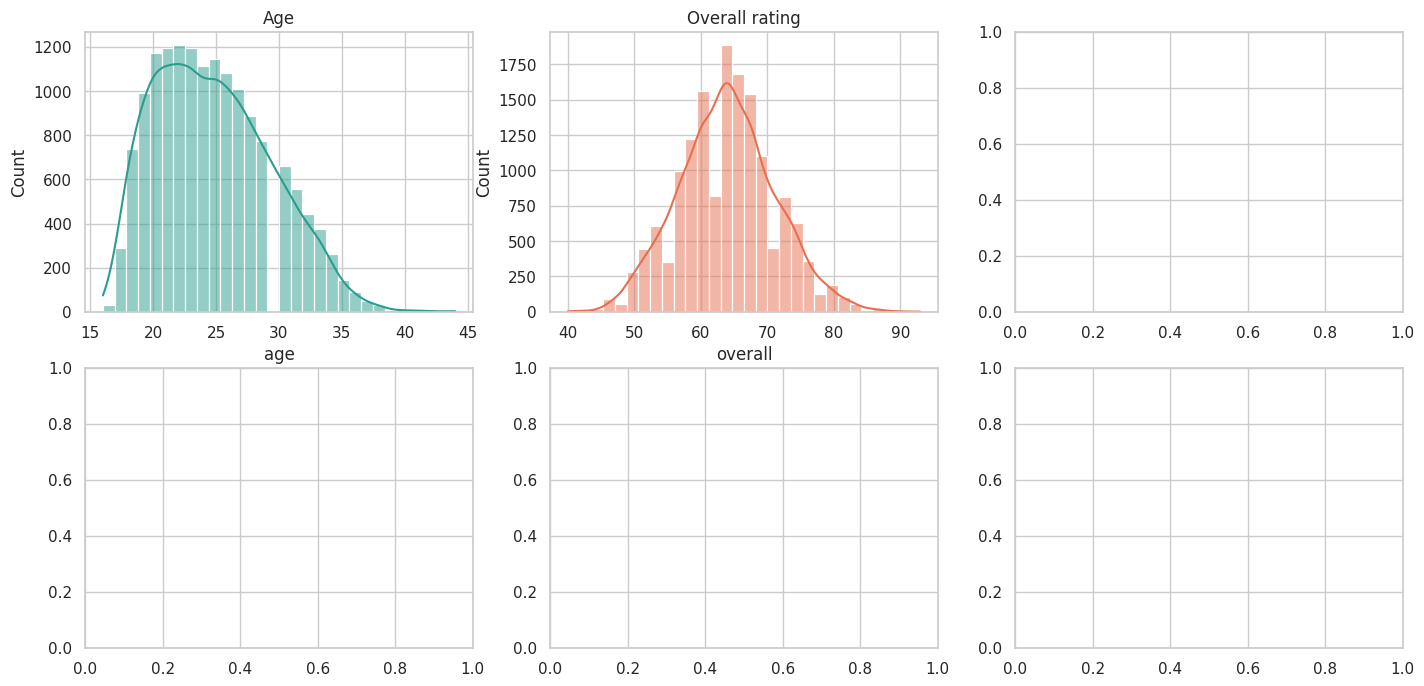

In [20]:
fig, ax = plt.subplots(2, 3, figsize=(17, 8))
sns.histplot(clean["age"], bins=30, kde=True, ax=ax[0,0], color="#2a9d8f");     ax[0,0].set_title("Age")
sns.histplot(clean["overall"], bins=30, kde=True, ax=ax[0,1], color="#e76f51");  ax[0,1].set_title("Overall rating")

Text(0.5, 1.0, 'Overall rating')

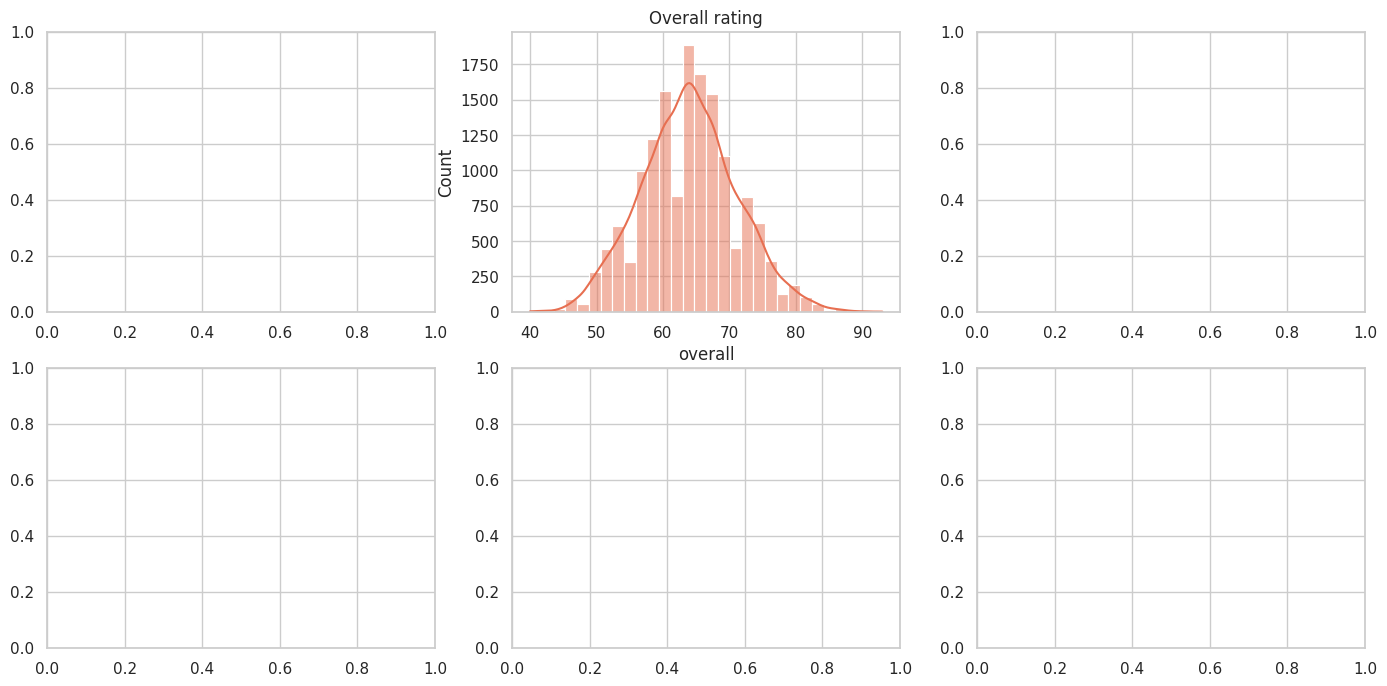

In [21]:
fig, ax = plt.subplots(2, 3, figsize=(17, 8))
sns.histplot(clean["overall"], bins=30, kde=True, ax=ax[0,1], color="#e76f51");  ax[0,1].set_title("Overall rating")

In [22]:
sns.histplot(clean["potential"], bins=30, kde=True, ax=ax[0,2], color="#264653");ax[0,2].set_title("Potential")

Text(0.5, 1.0, 'Potential')

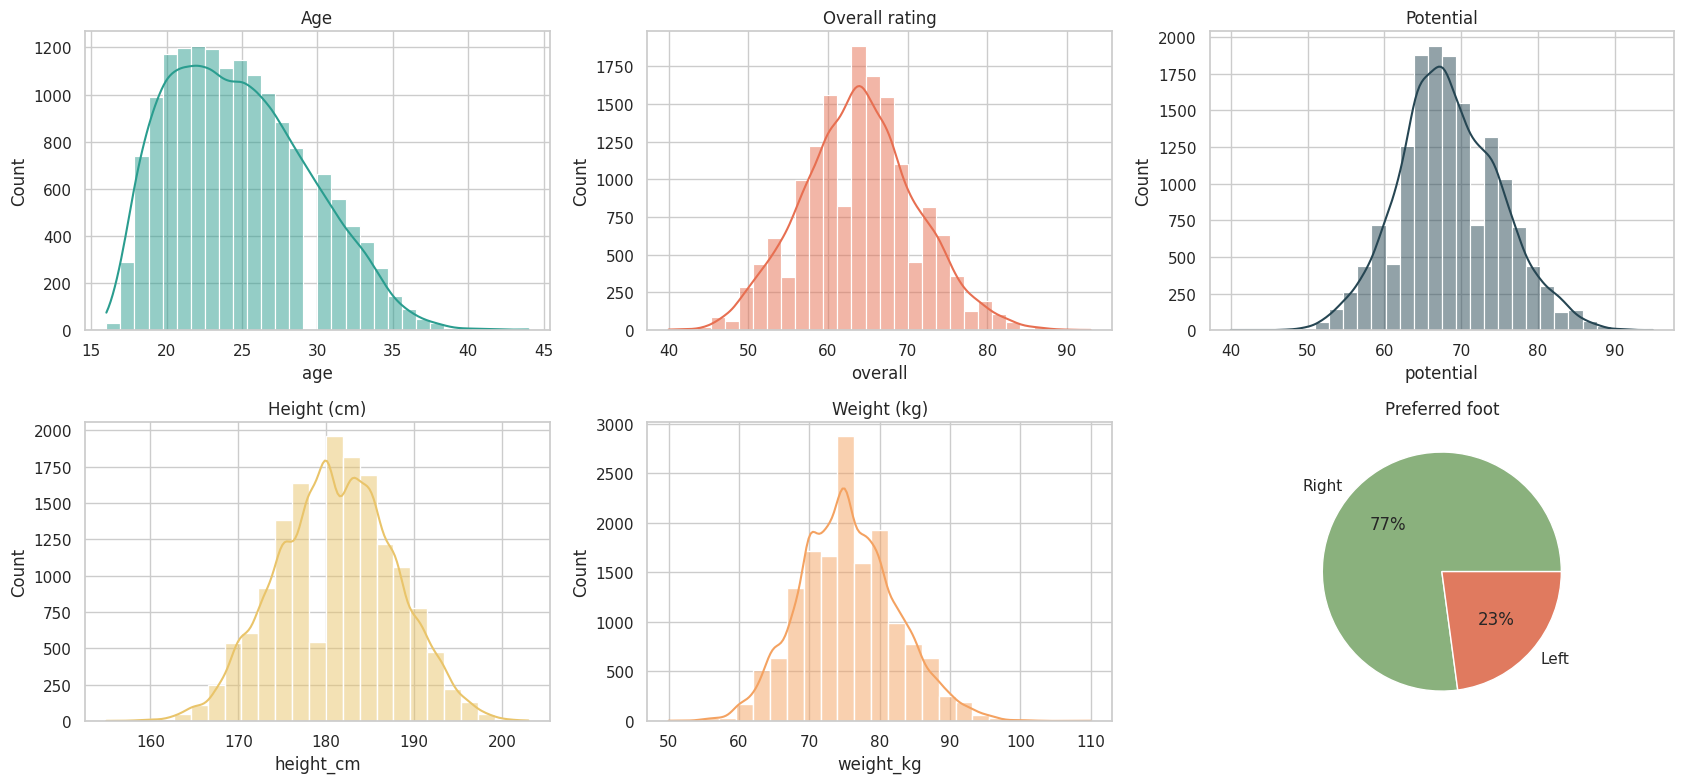

In [23]:
fig, ax = plt.subplots(2, 3, figsize=(17, 8))
sns.histplot(clean["age"], bins=30, kde=True, ax=ax[0,0], color="#2a9d8f");      ax[0,0].set_title("Age")
sns.histplot(clean["overall"], bins=30, kde=True, ax=ax[0,1], color="#e76f51");  ax[0,1].set_title("Overall rating")
sns.histplot(clean["potential"], bins=30, kde=True, ax=ax[0,2], color="#264653");ax[0,2].set_title("Potential")
sns.histplot(clean["height_cm"], bins=25, kde=True, ax=ax[1,0], color="#e9c46a");ax[1,0].set_title("Height (cm)")
sns.histplot(clean["weight_kg"], bins=25, kde=True, ax=ax[1,1], color="#f4a261");ax[1,1].set_title("Weight (kg)")
clean["preferred_foot"].value_counts().plot.pie(autopct="%1.0f%%", ax=ax[1,2], colors=["#8ab17d","#e07a5f"])
ax[1,2].set_ylabel(""); ax[1,2].set_title("Preferred foot")
plt.tight_layout(); plt.show()

In [24]:
clean[["age","overall","potential","height_cm","weight_kg"]].describe().round(1)

,age,overall,potential,height_cm,weight_kg
count,15465.0,15465.0,15465.0,15465.0,15465.0
mean,24.8,63.9,68.5,181.1,75.5
std,4.6,7.2,6.6,6.6,6.9
min,16.0,40.0,40.0,155.0,50.0
25%,21.0,59.0,64.0,176.0,70.0
50%,24.0,64.0,68.0,181.0,75.0
75%,28.0,69.0,73.0,186.0,80.0
max,44.0,93.0,95.0,203.0,110.0


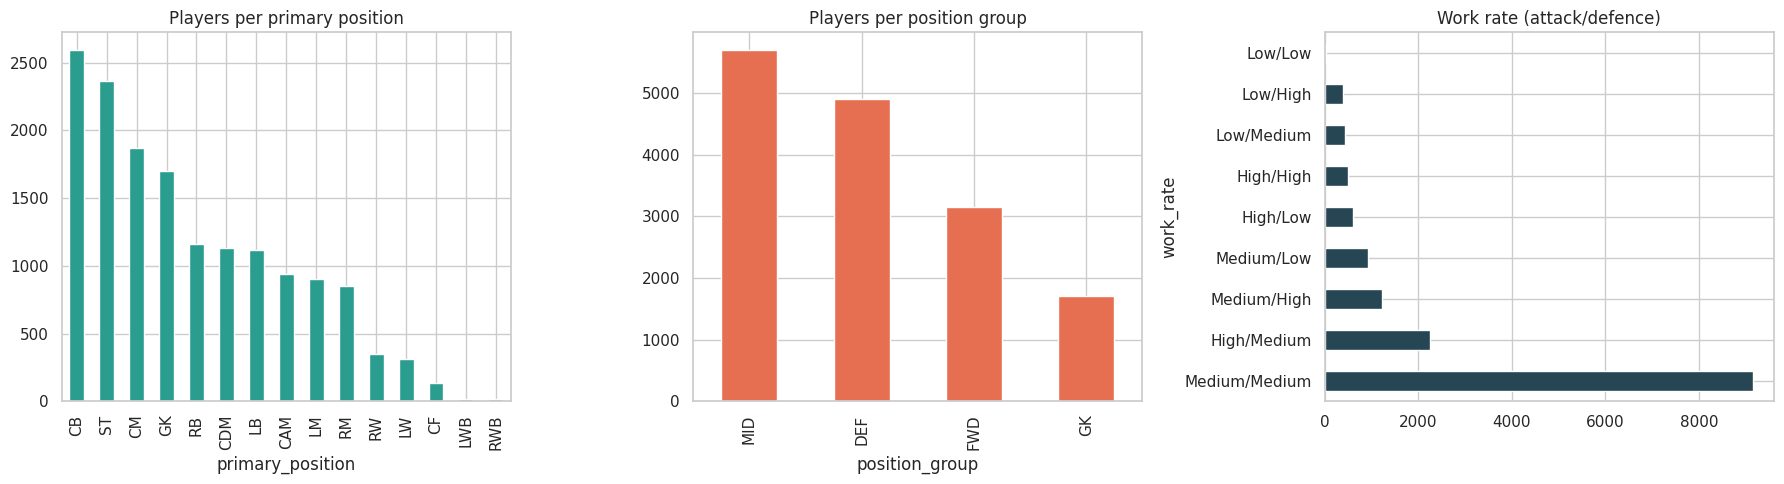

In [25]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
clean["primary_position"].value_counts().plot.bar(ax=ax[0], color="#2a9d8f"); ax[0].set_title("Players per primary position")
clean["position_group"].value_counts().plot.bar(ax=ax[1], color="#e76f51");   ax[1].set_title("Players per position group")
clean["work_rate"].value_counts().plot.barh(ax=ax[2], color="#264653");       ax[2].set_title("Work rate (attack/defence)")
plt.tight_layout(); plt.show()

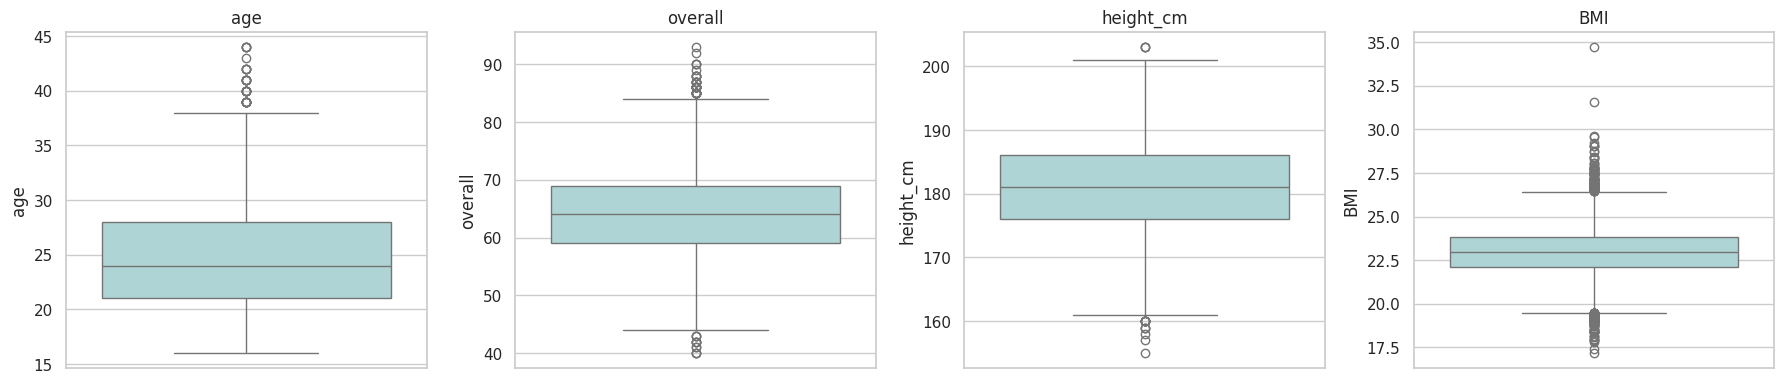

BMI outliers: 226 (real players – kept; we do not delete real athletes)


In [26]:
fig, ax = plt.subplots(1, 4, figsize=(18, 4))
for a, c in zip(ax, ["age", "overall", "height_cm", "BMI"]):
    sns.boxplot(y=clean[c], ax=a, color="#a8dadc"); a.set_title(c)
plt.tight_layout(); plt.show()
q1, q3 = clean["BMI"].quantile([.25, .75]); iqr = q3 - q1
print("BMI outliers:", ((clean["BMI"] < q1 - 1.5*iqr) | (clean["BMI"] > q3 + 1.5*iqr)).sum(),
      "(real players – kept; we do not delete real athletes)")

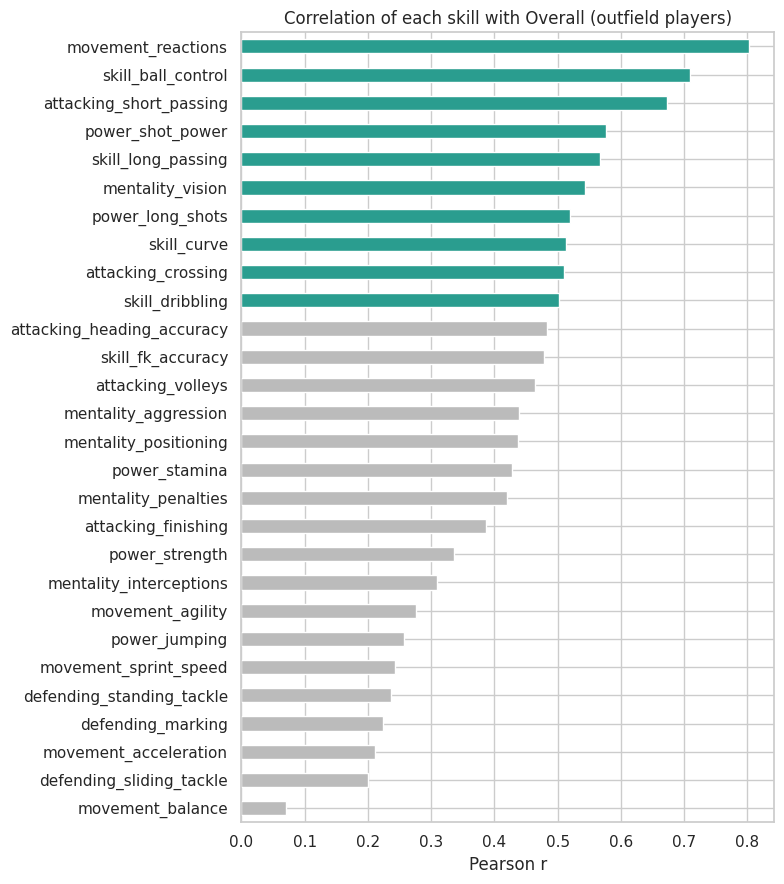

Top 5 most 'Overall-driving' skills:
 skill_long_passing         0.57
power_shot_power           0.58
attacking_short_passing    0.67
skill_ball_control         0.71
movement_reactions         0.80
Name: overall, dtype: float64


In [27]:
outfield = clean[clean.position_group != "GK"]
corr = outfield[skill_cols[:28] + ["overall"]].corr()["overall"].drop("overall").sort_values()
plt.figure(figsize=(8, 9))
corr.plot.barh(color=np.where(corr > 0.5, "#2a9d8f", "#bbbbbb"))
plt.title("Correlation of each skill with Overall (outfield players)"); plt.xlabel("Pearson r")
plt.tight_layout(); plt.show()
print("Top 5 most 'Overall-driving' skills:\n", corr.tail(5).round(2))

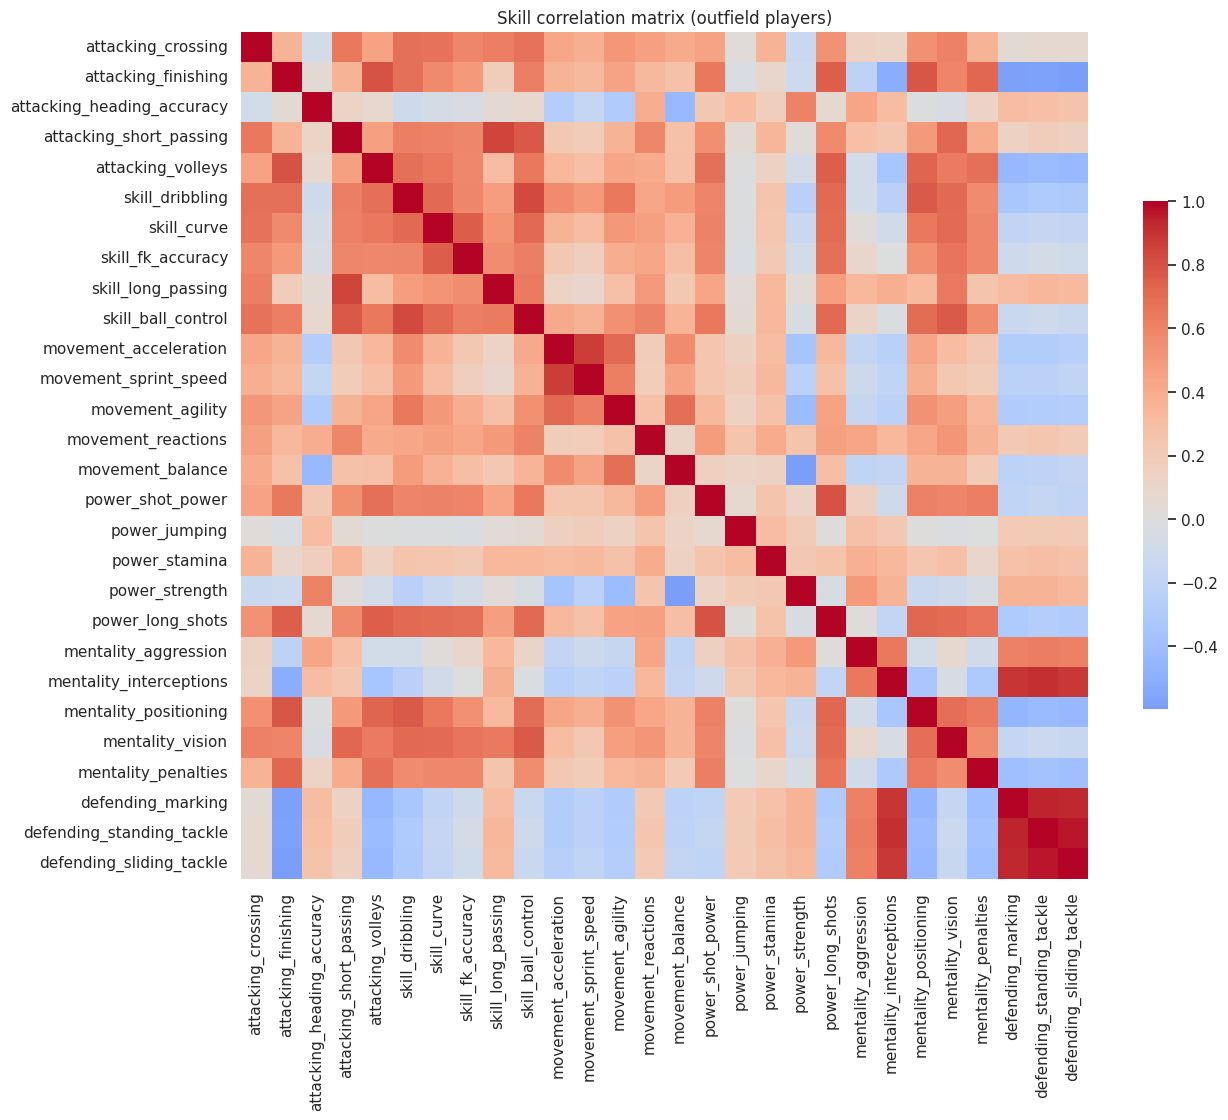

In [28]:
plt.figure(figsize=(14, 11))
sns.heatmap(outfield[skill_cols[:28]].corr(), cmap="coolwarm", center=0, square=True, cbar_kws={"shrink": .6})
plt.title("Skill correlation matrix (outfield players)"); plt.show()

In [29]:
top_clubs = (clean.groupby("club").agg(players=("overall","size"), avg_overall=("overall","mean"))
             .query("players >= 20").sort_values("avg_overall", ascending=False).head(10).round(1))
display(top_clubs)

pair = clean[clean.short_name.isin(["L. Messi", "Cristiano Ronaldo"])].set_index("short_name")
radar_cols = ["pace","shooting","passing","dribbling","defending","physic"]
pair[["age","overall","potential"] + radar_cols].T

,players,avg_overall
club,,
FC Barcelona,24,79.8
FC Bayern München,29,78.6
Paris Saint-Germain,24,77.7
Milan,27,76.7
Real Madrid,33,75.2
SL Benfica,30,75.0
Galatasaray SK,28,74.9
FC Porto,30,74.7
Atlético Madrid,29,74.4


short_name,L. Messi,Cristiano Ronaldo
age,27.0,29.0
overall,93.0,92.0
potential,95.0,92.0
pace,93.0,93.0
shooting,89.0,93.0
passing,86.0,81.0
dribbling,96.0,91.0
defending,27.0,32.0
physic,63.0,79.0


In [47]:
feature_cols = skill_cols + ["weak_foot", "skill_moves", "attack_work_rate", "defense_work_rate", "preferred_foot_enc"]
X = clean[feature_cols].copy()
print("Features:", len(feature_cols), "| missing:", X.isna().sum().sum(), "| players:", len(X))

Features: 38 | missing: 0 | players: 15465


Created X_pca with shape: (15465, 5) (explained variance: 76.59%)


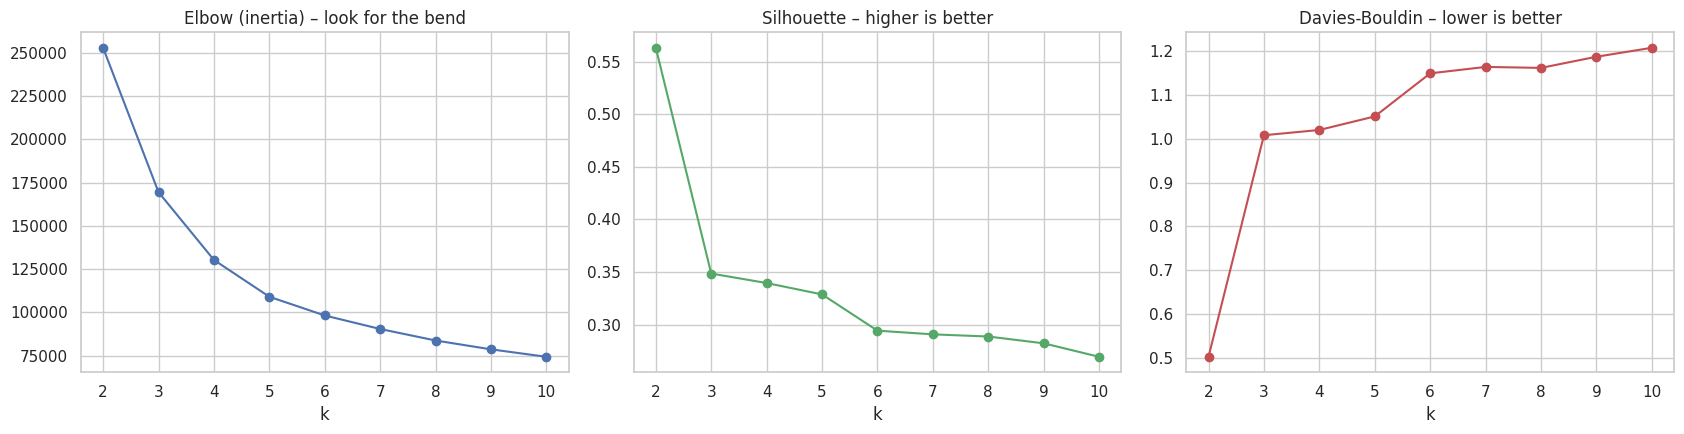

,silhouette,davies_bouldin,calinski
k,,,
2,0.563,0.503,12059.0
3,0.349,1.008,12801.0
4,0.339,1.020,12645.0
5,0.329,1.051,12086.0
6,0.294,1.149,11072.0
7,0.291,1.164,10245.0
8,0.289,1.162,9653.0
9,0.282,1.187,9119.0
10,0.269,1.208,8674.0


In [52]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1) Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2) Perform PCA
pca = PCA(n_components=5, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
print(f"Created X_pca with shape: {X_pca.shape} (explained variance: {pca.explained_variance_ratio_.sum():.2%})")

# 3) Run KMeans clustering metrics
ks = range(2, 11)
inertia, sil, dbi, chi = [], [], [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X_pca)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(X_pca, km.labels_, sample_size=5000, random_state=RANDOM_STATE))
    dbi.append(davies_bouldin_score(X_pca, km.labels_))
    chi.append(calinski_harabasz_score(X_pca, km.labels_))

fig, ax = plt.subplots(1, 3, figsize=(17, 4.5))
ax[0].plot(ks, inertia, "o-"); ax[0].set_title("Elbow (inertia) – look for the bend")
ax[1].plot(ks, sil, "o-", c="g");  ax[1].set_title("Silhouette – higher is better")
ax[2].plot(ks, dbi, "o-", c="r");  ax[2].set_title("Davies-Bouldin – lower is better")
for a in ax: a.set_xlabel("k")
plt.tight_layout(); plt.show()
pd.DataFrame({"k": list(ks), "silhouette": np.round(sil,3), "davies_bouldin": np.round(dbi,3), "calinski": np.round(chi)}).set_index("k")

,players,DEF,FWD,GK,MID
cluster,,,,,
0,5402,0.0,56.0,0.0,44.0
1,4272,78.0,1.0,0.0,21.0
2,1703,0.0,0.0,100.0,0.0
3,4088,38.0,3.0,0.0,60.0


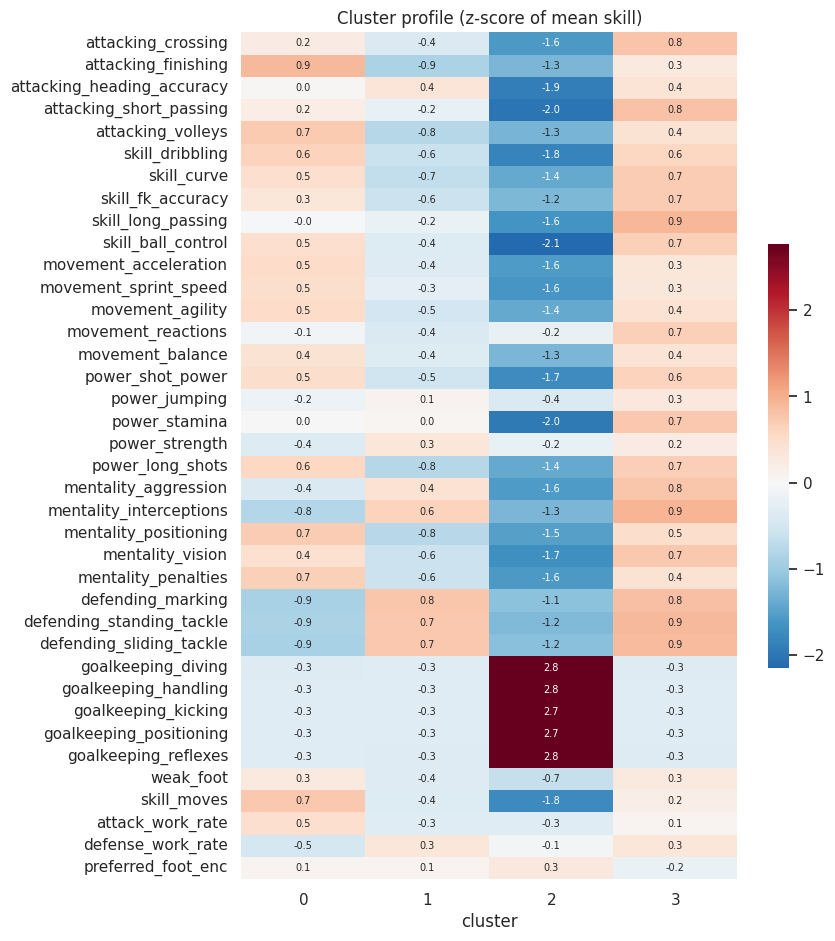

In [54]:
# 1) Fit the final KMeans model (using k=4 to capture tactical groups: GK, DEF, MID, FWD)
k_best = 4
km_final = KMeans(n_clusters=k_best, n_init=10, random_state=RANDOM_STATE)
clean["cluster"] = km_final.fit_predict(X_pca)

# 2) Profile the clusters
profile = clean.groupby("cluster")[feature_cols + ["overall", "age"]].mean().round(1)
size = clean["cluster"].value_counts().sort_index().rename("players")

# which position group dominates each cluster?
pos_mix = pd.crosstab(clean["cluster"], clean["position_group"], normalize="index").mul(100).round(0)
display(pd.concat([size, pos_mix], axis=1))

# z-score heatmap of the profile: what makes each cluster different from the average player?
z = (profile[feature_cols] - clean[feature_cols].mean()) / clean[feature_cols].std()
plt.figure(figsize=(8, 11))
sns.heatmap(z.T, cmap="RdBu_r", center=0, annot=True, fmt=".1f", annot_kws={"size": 7}, cbar_kws={"shrink": .5})
plt.title("Cluster profile (z-score of mean skill)"); plt.xlabel("cluster"); plt.show()

,Country,Players,Share_%
1,England,1579,10.2
2,Spain,1022,6.6
3,France,875,5.7
4,Argentina,861,5.6
5,Italy,778,5.0
6,Germany,695,4.5
7,Colombia,517,3.3
8,Republic of Ireland,453,2.9
9,Mexico,416,2.7
10,Chile,410,2.7


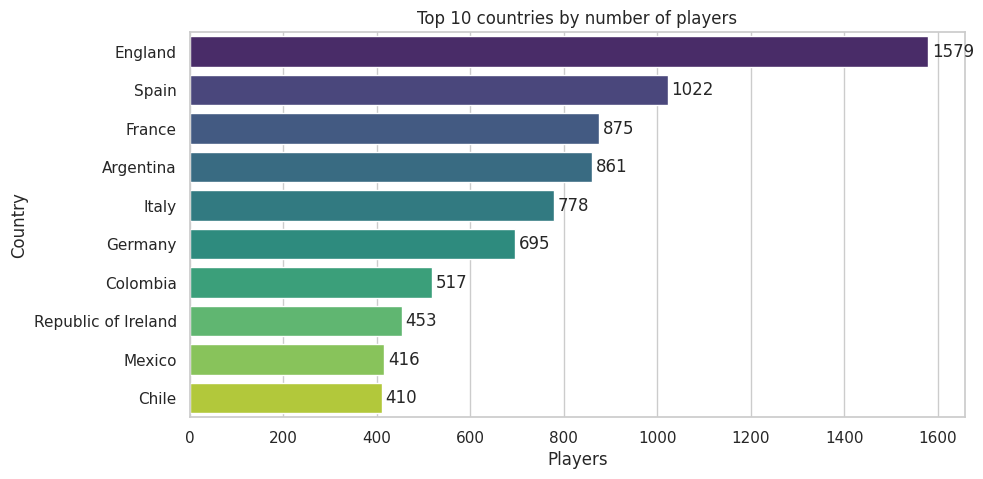

These 10 countries supply 49.2% of all 15,465 players out of 148 nations.


In [30]:
top10 = clean["nationality"].value_counts().head(10).rename_axis("Country").reset_index(name="Players")
top10["Share_%"] = (top10["Players"] / len(clean) * 100).round(1)
top10.index = top10.index + 1
display(top10)

plt.figure(figsize=(10, 5))
sns.barplot(data=top10, x="Players", y="Country", palette="viridis")
for i, v in enumerate(top10["Players"]): plt.text(v + 8, i, str(v), va="center")
plt.title("Top 10 countries by number of players"); plt.show()
print(f"These 10 countries supply {top10['Players'].sum()/len(clean)*100:.1f}% of all {len(clean):,} players "
      f"out of {clean['nationality'].nunique()} nations.")

In [38]:
age_stats = (clean.groupby("age").agg(n=("overall","size"), mean_overall=("overall","mean"),
                                       mean_potential=("potential","mean"))
             .query("n >= 30"))                       # ignore ages with too few players
age_stats["gain_vs_prev_year"] = age_stats["mean_overall"].diff()
age_stats["growth_room"] = age_stats["mean_potential"] - age_stats["mean_overall"]


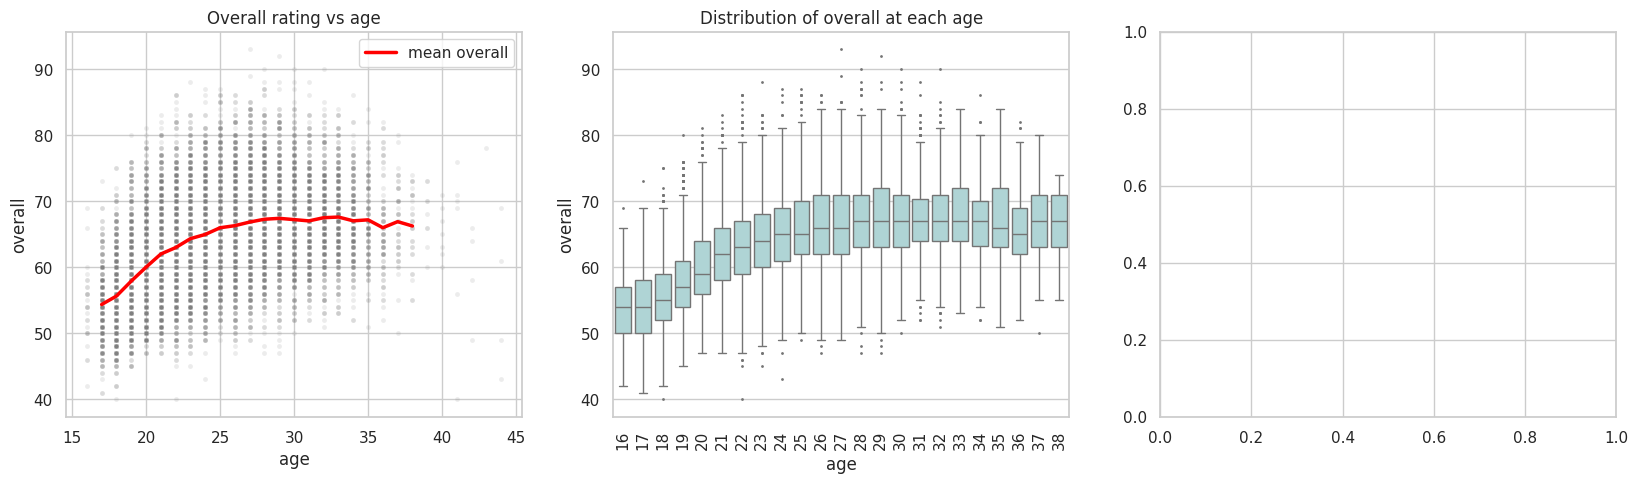

In [39]:
fig, ax = plt.subplots(1, 3, figsize=(20, 5))
sns.scatterplot(data=clean, x="age", y="overall", alpha=.15, s=12, ax=ax[0], color="gray")
sns.lineplot(data=age_stats, x=age_stats.index, y="mean_overall", ax=ax[0], color="red", lw=2.5, label="mean overall")
ax[0].set_title("Overall rating vs age")

sns.boxplot(data=clean[clean.age.between(16, 38)], x="age", y="overall", ax=ax[1], color="#a8dadc", fliersize=1)
ax[1].set_title("Distribution of overall at each age"); ax[1].tick_params(axis="x", rotation=90)


In [41]:
age_stats.round(2).loc[18:34]

,n,mean_overall,mean_potential,gain_vs_prev_year,growth_room
age,,,,,
18,738,55.62,67.12,1.27,11.49
19,990,57.89,68.36,2.27,10.47
20,1171,60.00,68.95,2.11,8.95
21,1196,62.00,69.47,1.99,7.47
22,1208,62.97,69.18,0.97,6.21
23,1195,64.32,69.69,1.35,5.37
24,1114,64.96,69.36,0.64,4.40
25,1146,65.97,69.53,1.01,3.56
26,1084,66.28,69.20,0.31,2.92


In [42]:
att = clean[clean["primary_position"].isin(["ST", "RW", "LW"])].copy()
att["position"] = att["primary_position"].map({"ST": "Striker", "RW": "Right winger", "LW": "Left winger"})

if clean["wage_eur"].sum() > 0:
    metric, label = "wage_eur", "Weekly wage (EUR)"
    att = att[att[metric] > 0]
else:
    metric, label = "overall", "Overall rating (PROXY – wages are 0 in this file)"
print("Metric used:", label)

summary = att.groupby("position")[metric].agg(["count", "mean", "median", "max"]).round(1).sort_values("mean", ascending=False)
display(summary)

Metric used: Overall rating (PROXY – wages are 0 in this file)


,count,mean,median,max
position,,,,
Left winger,314,66.8,67.0,92
Right winger,347,65.2,65.0,84
Striker,2362,63.9,64.0,90


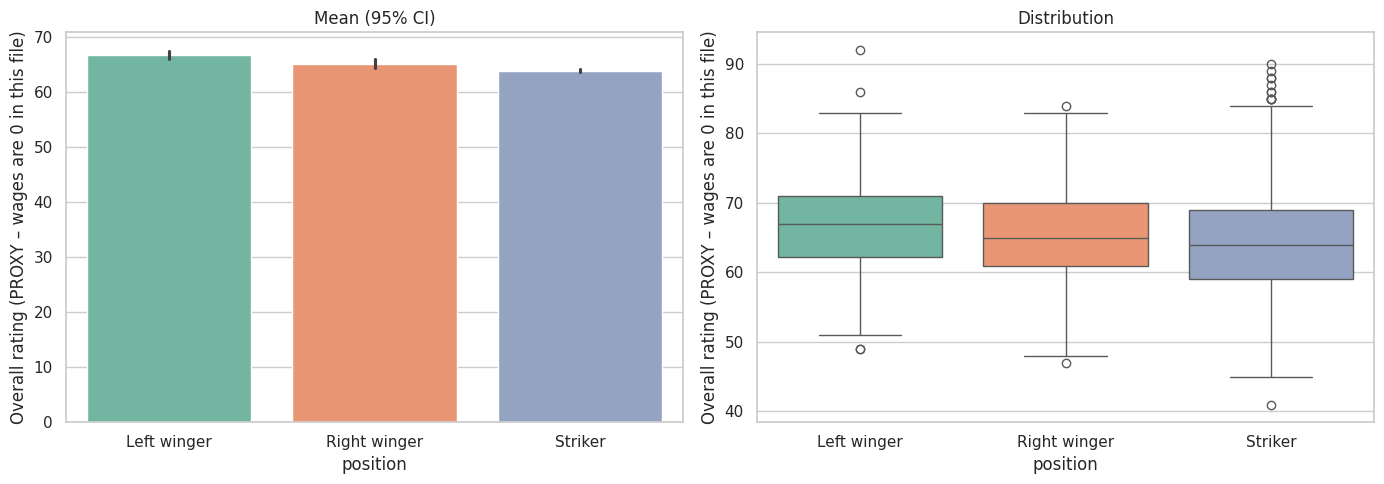

In [43]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
order = summary.index.tolist()
sns.barplot(data=att, x="position", y=metric, order=order, ax=ax[0], palette="Set2", errorbar=("ci", 95))
ax[0].set_title("Mean (95% CI)"); ax[0].set_ylabel(label)
sns.boxplot(data=att, x="position", y=metric, order=order, ax=ax[1], palette="Set2")
ax[1].set_title("Distribution"); ax[1].set_ylabel(label)
plt.tight_layout(); plt.show()

In [44]:
groups = [g[metric].values for _, g in att.groupby("position")]
H, p = stats.kruskal(*groups)
print(f"Kruskal-Wallis H = {H:.2f}, p-value = {p:.4g}  ->", "significant difference" if p < .05 else "no significant difference")
for a, b in [("Striker","Right winger"), ("Striker","Left winger"), ("Right winger","Left winger")]:
    u, pp = stats.mannwhitneyu(att[att.position==a][metric], att[att.position==b][metric])
    print(f"{a:13s} vs {b:13s}: p = {pp:.4g}")

Kruskal-Wallis H = 54.78, p-value = 1.274e-12  -> significant difference
Striker       vs Right winger : p = 0.00124
Striker       vs Left winger  : p = 2.496e-12
Right winger  vs Left winger  : p = 0.002445


In [45]:
elite = att.groupby("position")[metric].apply(lambda x: x.nlargest(50).mean()).round(1).sort_values(ascending=False)
print("Mean of top-50 per role:\n", elite)

Mean of top-50 per role:
 position
Striker         82.4
Left winger     76.7
Right winger    76.4
Name: overall, dtype: float64


In [46]:
feature_cols = skill_cols + ["weak_foot", "skill_moves", "attack_work_rate", "defense_work_rate", "preferred_foot_enc"]
X = clean[feature_cols].copy()
print("Features:", len(feature_cols), "| missing:", X.isna().sum().sum(), "| players:", len(X))


Features: 38 | missing: 0 | players: 15465
